# Coding Project 1 : Linear Regression and Regularization

**Please write the names of all group members here:**

Avesta Khaliqi (24-962-763)

Maximilian Flug (24-936-742)

Minghan Yang (24-941-197)

Ken Rölli (20-123-550)



---


*Note:* The provided structure for the code below is only suggestive, and if you want to structure your programs differently you may do so.

### Question 1 - Importing the Data

#### 1.a 

In [44]:
#For Question 1, you can import the following packages:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection  import train_test_split

#1.a) Import the dataset Housing.csv into Python as a pandas DataFrame.
#To determine whether a variable is categorical or numerical, please refer to the file data_description.txt.
#Remember that the first column of the csv file is an index column and should not be considered as an explanatory variable.
housing_df = pd.read_csv("Housing.csv", index_col=0)



#### 1.b 
Below we plot the SalePrice in a histogram, in original scale and in log scale, respectively. In the original scale, we can see that the data is right-skewed, and we picked log-transformation to make it closer to normally distributed. The log transform itself compresses large values making the distirbutition more symmetric and suitable for statistical analysis that assume normality. In the setting where the ground truth model is linear and has independent Gaussian noise we can use this even to construct statistical tests.

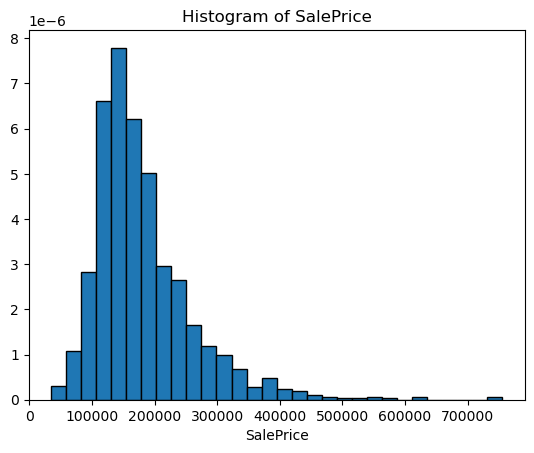

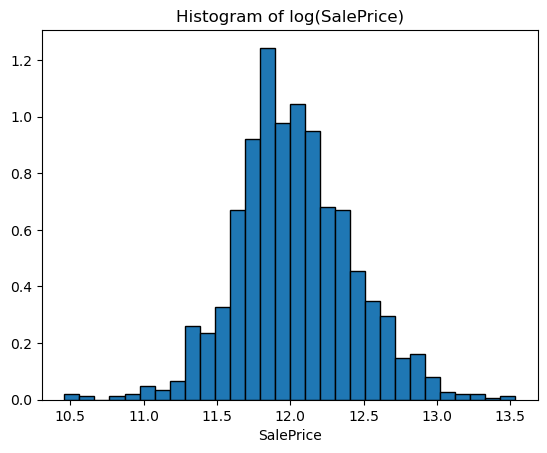

In [45]:
#1.b) Graphically determine whether the target variable SalePrice is approximately Gaussian.
# Plot the histogram and make sure to use 'density=True' to normalize it. So we can afterwards add a Gaussian density curve
# for comparison.


y = housing_df["SalePrice"]
X = housing_df.drop("SalePrice", axis=1)

# Plot histogram of SalePrice
plt.hist(y, bins=30, edgecolor='k', density='True')
plt.title("Histogram of SalePrice")
plt.xlabel("SalePrice")
plt.show()

# Plot histogram of log(SalePrice) and log-transform SalePrice
y = np.log(y)
plt.hist(y, bins=30, edgecolor='k', density='True')
plt.title("Histogram of log(SalePrice)")
plt.xlabel("SalePrice")
plt.show()

#### 1.c
We split the training data into 70% and 30% splits

In [46]:
#1.c) Split the data into a training set (X,y)_train and a test set (X,y)_test.
# We set a seed for reproducibility.
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



#### 1.d
We replace the missing values according to the assignment.

In [47]:
#1.d) Replace missing values in X using the training data statistics only -> use .fillna(...)
#For numerical features, replace missing values with the mean of the column .
#For categorical features, replace missing values with the most frequent category.
#You can use the function df.select_dtypes(...) to idetify categorical variables as the variables with type 'object' and 'category'. 
#Some categorical variables admit NA (or None) as a valid category, which should be treated as an actual level and not as missing.


numerical_variables = list(X.select_dtypes(include=['number']).columns)
# Categorical variables that are numerical in the data set but should be treated as categorical (see data_description.txt)
force_categorical = ['MSSubClass']
[numerical_variables.remove(var) for var in force_categorical]
categorical_variables = list(X.select_dtypes(exclude=['number']).columns) + force_categorical

# These categorical variables have "NA" as a valid category
categorical_nan_cat_variables = [
    "MasVnrType", "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType",
    "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "MiscFeature"
]

# Remove the categorical_nan_cat_variables from the categorical_variables list, as we will treat them separately
categorical_variables = [var for var in categorical_variables if var not in categorical_nan_cat_variables]

# For numerical variables, replace NaN with the mean of the training set
for variable in numerical_variables:
    mean_value = X_train[variable].mean()
    X_train[variable] = X_train[variable].fillna(mean_value)
    X_test[variable] = X_test[variable].fillna(mean_value)

# For regular categorical variables, replace NaN with the most frequent category of the training set
for variable in categorical_variables:
    # calculate the most frequent category in the training set
    most_frequent_value = X_train[variable].mode()[0]
    # imputing in test and train set
    X_train[variable] = X_train[variable].fillna(most_frequent_value)
    X_test[variable] = X_test[variable].fillna(most_frequent_value)

# For categorical variables with NA as valid category 'Valid_NA' string
for variable in categorical_nan_cat_variables:
    X_train[variable] = X_train[variable].fillna('Valid_NA')
    X_test[variable] = X_test[variable].fillna('Valid_NA')

# Standardize numerical variables to have mean 0 and std 1 in the training set. Apply the same transformation to the test set.
for variable in numerical_variables:
    mean_value, std = X_train[variable].mean(), X_train[variable].std()
    X_train[variable] = (X_train[variable] - mean_value) / std
    X_test[variable] = (X_test[variable] - mean_value) / std

# One-hot encode categorical variables and drop one level (avoid colinearity)
X_train = pd.get_dummies(X_train, columns=categorical_variables + categorical_nan_cat_variables, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_variables + categorical_nan_cat_variables, drop_first=True)

# Reinddex test set and fill zeros for unseen categories in training set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Ensure same number of features in training and test set
if np.shape(X_test)[1] != np.shape(X_train)[1]:
    print("Different number of features in training and test set!")
else:
    print("Same number of features in training and test set!")

Same number of features in training and test set!


### Question 2 - Linear Regression on Numerical Features

#### 2.a
Below we fit a linear regression model using sklearn and provide in- and out-of-sample MSE and R^2.

The MSE measure how well the regression surface fits the observed response variables.
Here in-sample MSE measures this fit on the training data and out-of-sample MSE measures the fit on the test data.
R^2 measures the proportion of variance explained by the linear model compared to the total variance just contained in the observed response.
Again in-sample R^2 measures this fit on the training data and out-of-sample R^2 measures the fit on the test data.

We note that on the transformed scale In-Sample and Out-of-Sample MSE and in-sample and Out-of-Sample R^2 are very close which indicates that model generalizes well and suggests that the model does not overfit. Further the R^2 value is positive and at .85 / .86 for in-sample/out-of-sample which suggests that we can expplain a significant portion of variance through the numerical features (in a linear model).

The RMSE even becomes interpretable on the original scale: The square root of the MSE on the original scale is at around 38.000/29.000 dollars for in-sample/out-of-sample.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm

#2.a) Fit a linear regression model on the training dataset with numerical features only using the sklearn package.
#Output a table with the name of each feature and the associated regression coefficient.


X_train_num = X_train[numerical_variables] # All numerical columns that we have standardized just before.
X_test_num = X_test[numerical_variables]
# We found that log(SalePrice) is much closer to a Gaussian distribution than SalePrice itself. So we use log(SalePrice) as target variable (we already transformed it in Q1)


model = LinearRegression(fit_intercept=True)
model.fit(X_train_num, y_train)
coefficients = pd.Series(model.coef_, index=X_train_num.columns) # The intercept is not included in model.coef_

y_train_pred = model.predict(X_train_num)
y_test_pred = model.predict(X_test_num)

# Define a function to reduce code duplication
def calculate_MSE_R2(y_true, y_pred):
    MSE = mean_squared_error(y_true, y_pred)
    R2 = r2_score(y_true, y_pred)
    return MSE, R2

# Define method to calculate R^2 and MSE in-sample and out-of-sample on transformed (log) and original scale
def calculate_train_test_metrics(y_train_true, y_train_pred, y_test_true, y_test_pred):
    # MSE and R2 for training and test on the transformed scale
    insample_MSE, insample_R2 = calculate_MSE_R2(y_train_true, y_train_pred)
    outofsample_MSE, outofsample_R2 = calculate_MSE_R2(y_test_true, y_test_pred)

    # MSE and R2 for training and test on the original scale (invert the log by exp)
    insample_MSE_ori, insample_R2_ori = calculate_MSE_R2(np.exp(y_train_true), np.exp(y_train_pred))
    outofsample_MSE_ori, outofsample_R2_ori = calculate_MSE_R2(np.exp(y_test_true), np.exp(y_test_pred))
    
    metrics_df = pd.DataFrame(columns=["In-sample MSE", "Out-of-sample MSE", "In-sample R2", "Out-of-sample R2"], index=["Transformed Scale (log(SalePrice))", "Original Scale"])
    metrics_df.loc["Transformed Scale (log(SalePrice))"] = [insample_MSE, outofsample_MSE, insample_R2, outofsample_R2]
    metrics_df.loc["Original Scale"] = [insample_MSE_ori, outofsample_MSE_ori, insample_R2_ori, outofsample_R2_ori]
    return metrics_df


      

num_lin_reg_metrics = calculate_train_test_metrics(y_train, y_train_pred, y_test, y_test_pred)
print("Numerical Linear Regression Metrics:")
print(num_lin_reg_metrics)
print("-------------------------")

# Output the coefficients in a table (including intercept)

# Coefficients table
coef_table = pd.DataFrame({
    "Feature": ["Intercept"] + list(numerical_variables),
    "Coefficient": [model.intercept_] + list(model.coef_)
})
print('Coefficient table including Intercept:')
print(coef_table)

Numerical Linear Regression Metrics:
                                        In-sample MSE Out-of-sample MSE  \
Transformed Scale (log(SalePrice))           0.021996           0.02187   
Original Scale                      1433793965.686363  829114329.134467   

                                   In-sample R2 Out-of-sample R2  
Transformed Scale (log(SalePrice))     0.858098         0.871086  
Original Scale                         0.761772         0.881183  
-------------------------
Coefficient table including Intercept:
          Feature  Coefficient
0       Intercept    12.028893
1     LotFrontage    -0.001184
2         LotArea     0.021460
3     OverallQual     0.114339
4     OverallCond     0.047950
5       YearBuilt     0.091427
6    YearRemodAdd     0.027565
7      MasVnrArea    -0.006483
8      BsmtFinSF1     0.009727
9      BsmtFinSF2     0.001544
10      BsmtUnfSF     0.002211
11    TotalBsmtSF     0.012726
12       1stFlrSF     0.039123
13       2ndFlrSF     0.019685
14   L

#### 2.b.i

In [49]:
#2.b) (i) Compute the estimated coefficients for each explanatory variable using the numpy package. 
#Remember that the design matrix A needs to include a column of 1's. Use np.linalg.solve(...).
X_train_np = X_train_num.to_numpy()
y_train_np = y_train.to_numpy()
intercept = np.ones((np.shape(X_train_np)[0], 1))
A = np.hstack([intercept, X_train_np])

beta_hat = np.linalg.solve(np.transpose(A) @ A, np.transpose(A) @ y_train_np)

coefficient_estimates_df = pd.DataFrame(data={"Feature": ["Intercept"] + list(X_train_num.columns), "Coefficient": beta_hat})
print("Coefficient Estimates (numpy):")
print(coefficient_estimates_df)
print("-------------------------")


Coefficient Estimates (numpy):
          Feature  Coefficient
0       Intercept    12.028893
1     LotFrontage    -0.001184
2         LotArea     0.021460
3     OverallQual     0.114339
4     OverallCond     0.047950
5       YearBuilt     0.091427
6    YearRemodAdd     0.027565
7      MasVnrArea    -0.006483
8      BsmtFinSF1     0.589622
9      BsmtFinSF2     0.192178
10      BsmtUnfSF     0.564499
11    TotalBsmtSF    -0.551351
12       1stFlrSF    -0.146065
13       2ndFlrSF    -0.190021
14   LowQualFinSF    -0.017376
15      GrLivArea     0.297965
16   BsmtFullBath     0.034196
17   BsmtHalfBath     0.003012
18       FullBath     0.016306
19       HalfBath     0.011662
20   BedroomAbvGr     0.006731
21   KitchenAbvGr    -0.024333
22   TotRmsAbvGrd     0.030204
23     Fireplaces     0.033572
24    GarageYrBlt    -0.011872
25     GarageCars     0.059927
26     GarageArea     0.011736
27     WoodDeckSF     0.015838
28    OpenPorchSF    -0.004768
29  EnclosedPorch     0.012229
30      

#### 2.b.ii

In [50]:
# (ii) Compute the standard error of each estimated coefficient using the numpy package.
m = np.shape(y_train_np)[0]
d = np.shape(X_train_np)[1]
sigma2 = 1 / (m - (d + 1)) * np.sum((y_train_np - A @ beta_hat) ** 2) 
AT_A = np.transpose(A) @ A
AT_A_inv = np.linalg.solve(AT_A, np.eye(np.shape(AT_A)[0]))


var_beta_hat = sigma2 * AT_A_inv


# The standard errors are the square root of the diagonal elements of var_beta_hat
# np.diag gets the diagonal elements of the matrix
standard_errors = np.sqrt(np.diag(var_beta_hat))


standard_errors_df = pd.DataFrame(data={"Feature": ["Intercept"] + list(X_train_num.columns), "Standard Errors": standard_errors})
print("Standard errors (numpy):")
print(standard_errors_df)
print("-------------------------")

# COMMENT: The standard errors of most coefficients are quite small (between 0.001 and 0.01)



Standard errors (numpy):
          Feature  Standard Errors
0       Intercept         0.004723
1     LotFrontage         0.005668
2         LotArea         0.005318
3     OverallQual         0.008462
4     OverallCond         0.005957
5       YearBuilt         0.010843
6    YearRemodAdd         0.007468
7      MasVnrArea         0.005633
8      BsmtFinSF1    150214.843508
9      BsmtFinSF2     49381.499497
10      BsmtUnfSF    145653.694552
11    TotalBsmtSF    146117.072709
12       1stFlrSF     89194.938044
13       2ndFlrSF    101003.880697
14   LowQualFinSF     10978.957192
15      GrLivArea    121576.009713
16   BsmtFullBath         0.007026
17   BsmtHalfBath         0.005165
18       FullBath         0.008027
19       HalfBath         0.006854
20   BedroomAbvGr         0.007396
21   KitchenAbvGr         0.005643
22   TotRmsAbvGrd         0.010651
23     Fireplaces         0.005959
24    GarageYrBlt         0.008588
25     GarageCars         0.010988
26     GarageArea         0.01

#### 2.b.iii

In [51]:
# (iii) Compute the (in-sample) MSE and R^2 using the numpy package
y_train_pred_np = A @ beta_hat
SSR = np.sum((y_train_np - y_train_pred_np) ** 2) # Sum of squared residuals
SST = np.sum((y_train_np - np.mean(y_train_np)) ** 2) # Sum of total squares

# Transformed scale
MSE = 1 / m * SSR
R2 = 1 - SSR / SST

# Original scale
MSE_ori = 1 / m * np.sum((np.exp(y_train_np) - np.exp(y_train_pred_np)) ** 2)
R2_ori = 1 - np.sum((np.exp(y_train_np) - np.exp(y_train_pred_np)) ** 2) / np.sum((np.exp(y_train_np) - np.mean(np.exp(y_train_np))) ** 2)

num_lin_reg_metrics_np = pd.DataFrame(columns=["In-sample MSE", "In-sample R2"], index=["Transformed Scale (log(SalePrice))", "Original Scale"])
num_lin_reg_metrics_np.loc["Transformed Scale (log(SalePrice))"] = [MSE, R2]
num_lin_reg_metrics_np.loc["Original Scale"] = [MSE_ori, R2_ori]
print("Numerical Linear Regression Metrics (using numpy):")
print(num_lin_reg_metrics_np)
print("-------------------------")

Numerical Linear Regression Metrics (using numpy):
                                        In-sample MSE In-sample R2
Transformed Scale (log(SalePrice))           0.021996     0.858098
Original Scale                      1433793965.686343     0.761772
-------------------------


#### 2.b.iv

Most coefficients and standard errors stay the same, apart from the ones where we already had large standard errors in 2.b.ii (features 8-15). Here the coefficients and standard errors calculates by the pseudoinverse differe storngly from the ones calculated using basic inversion in numpy. If (A^T A)^(-1) does not exist or is very close to not existing (eigenvalues very close to zero), the results can change. The high standard errors from the previous task imply that one could have almost colinear columns (this makes sense, since the columns with high standard errors deal with square footage, such that SF-counts like the total square footag of the basement should be the sum of finished and unfinished (types) square footage of the basement (BsmtUnfSF, BsmtFinSF1 and BsmtUNFSF2)). The columns almost being multicolinear makes the calculation of the regression coefficients unstable and succeptable to small differences (numerical precision) which is why we see the differences in the calculated coefficients and standard errors (we display the norm of the difference vectors of the coefficients and the standard errors below). By the same reasoning for the columns with low standard error in 2.b.ii. we get very similar results in the coefficients and standard errors.

In [52]:
# (iv) Do the results change using pseudoinversion instead of standard matrix inversion? Use np.linalg.pinv(...).
beta_hat_pinv = np.linalg.pinv(A)  @ y_train_np

sigma2_pinv = 1 / (m - (d + 1)) * np.sum((y_train_np - A @ beta_hat) ** 2) 

AT_A_inv = np.linalg.pinv(AT_A)

var_beta_hat_pinv = sigma2_pinv * AT_A_inv
standard_errors_pinv = np.sqrt(np.diag(var_beta_hat_pinv))

coefficient_estimates_df["Standard Errors"] = standard_errors
coefficient_estimates_df["Coef (pinv)"] = beta_hat_pinv
coefficient_estimates_df["SE (pinv)"] = standard_errors_pinv
coefficient_estimates_df["Difference coef (numpy - pinv)"] = coefficient_estimates_df["Coefficient"] - coefficient_estimates_df["Coef (pinv)"]
coefficient_estimates_df["Difference SE (numpy - pinv)"] = coefficient_estimates_df["Standard Errors"] - coefficient_estimates_df["SE (pinv)"]
print("Coefficient Estimates Comparison (Standard versus pseudoinversion):")
print(coefficient_estimates_df)
print("-------------------------")

print("Difference in norm of beta_hat (numpy - pinv):", np.linalg.norm(beta_hat - beta_hat_pinv))
print("Difference in norm of standard errors (numpy - pinv):", np.linalg.norm(standard_errors - standard_errors_pinv))

Coefficient Estimates Comparison (Standard versus pseudoinversion):
          Feature  Coefficient  Standard Errors  Coef (pinv)  SE (pinv)  \
0       Intercept    12.028893         0.004723    12.028893   0.004723   
1     LotFrontage    -0.001184         0.005668    -0.001184   0.005668   
2         LotArea     0.021460         0.005318     0.021460   0.005318   
3     OverallQual     0.114339         0.008462     0.114339   0.008462   
4     OverallCond     0.047950         0.005957     0.047950   0.005957   
5       YearBuilt     0.091427         0.010843     0.091427   0.010843   
6    YearRemodAdd     0.027565         0.007468     0.027565   0.007468   
7      MasVnrArea    -0.006483         0.005633    -0.006483   0.005633   
8      BsmtFinSF1     0.589622    150214.843508     0.009727   0.005303   
9      BsmtFinSF2     0.192178     49381.499497     0.001544   0.004894   
10      BsmtUnfSF     0.564499    145653.694552     0.002211   0.004707   
11    TotalBsmtSF    -0.551351  

#### 2.b.v
We confirm the results of 2.b.i with the statsmodels package.

The difference in norm between the calculated coefficient vectors rounds to 0, which confirms the correctness of the calculation of coefficients in 2.b.i.

The difference in norm between the calculated standard error vectors is of order 10e-5, which confirms the correctness of the calculation of standard errors in 2.b.ii.



In [53]:
# (v) Compare your results (with and without pseudoinversion) to the output of the sm.OLS(...) function.
OLS_fit = sm.OLS(y_train, sm.add_constant(X_train_num)).fit()
print(OLS_fit.summary())

print(f"L1 norm(OLS Beta - Matrix Algebra Beta): {np.linalg.norm(OLS_fit.params - beta_hat_pinv)}")
print(f"L1 norm(OLS SE's - Matrix Algebra SE's): {np.linalg.norm(OLS_fit.bse - standard_errors_pinv)}")

# The Betas match up to numerical rounding (10^(-14))
# The standard errors are almost identical, but still off by 10^(-5)

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     181.0
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:36:40   Log-Likelihood:                 500.29
No. Observations:                1022   AIC:                            -932.6
Df Residuals:                     988   BIC:                            -765.0
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            12.0289      0.005   2549.387

### Question 3 - Regularization Techniques

#### 3.a
The in-sample metrics necessarily improve, since we include new features, however the out-of-sample metrics indicate that the model does not generalize well:

The Out-of-sample MSE is considerably larger than the in-sample MSE (by factor ~ 66 on log-scale and ~13 on original scale, see code output), which suggests that the regression surface overfits to noise in the training data and does not generalize to the test data. Further the squareroot of the MSE is of order ~130.000 which is considerably large considering that the mean of the sales prices is of order~180.000 (see code output)
Also the out-of-sample R2 is even negative, which means that on the test set, the model performs worse than the constant model (always predicting the mean of the response variable).
This shows that with all explanatory variables, the linear model is not able to generalize well to unseen data.

In [54]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, RepeatedKFold, KFold

# 3.a) Linear regression with the full Housing dataset (numerical + categorical).
#How do the in-sample and out-of-sample metrics change when including categorical features, and what does this reveal about the model’s ability to generalize?

full_lin_reg = LinearRegression(fit_intercept=True)

# We include the full feature set (numerical & categorical)
X_train_full = X_train
X_test_full = X_test

full_fit = full_lin_reg.fit(X_train_full, y_train)

y_train_full_pred = full_fit.predict(X_train_full)
y_test_full_pred = full_fit.predict(X_test_full)

# Show the full linear regression metrics
full_lin_reg_metrics = calculate_train_test_metrics(y_train, y_train_full_pred, y_test, y_test_full_pred)
print("Full Linear Regression Metrics:")
print(full_lin_reg_metrics)
print("-------------------------")

# Show the numerical linear regression metrics again for comparison
print("Numerical Linear Regression Metrics:")
print(num_lin_reg_metrics)
print("-------------------------")

# We show the factor by which out-of-sample MSE increases compared to in-sample MSE
print("-------------------------")
print("Factor increase of out-of-sample MSE compared to in-sample MSE (log scale):")
print("Numerical Linear Regression:", full_lin_reg_metrics.loc["Transformed Scale (log(SalePrice))", "Out-of-sample MSE"] / num_lin_reg_metrics.loc["Transformed Scale (log(SalePrice))", "In-sample MSE"])
print("Factor increase of out-of-sample MSE compared to in-sample MSE (original scale):")
print("Numerical Linear Regression:", full_lin_reg_metrics.loc["Original Scale", "Out-of-sample MSE"] / num_lin_reg_metrics.loc["Original Scale", "In-sample MSE"])
print("Square root of out-of-sample MSE in original scale (Full Linear Regression):")
print(np.sqrt(full_lin_reg_metrics.loc["Original Scale", "Out-of-sample MSE"]))
print("Mean of SalesPrice (to compare with RMSE):")
print(np.mean(np.exp(y)))

Full Linear Regression Metrics:
                                       In-sample MSE   Out-of-sample MSE  \
Transformed Scale (log(SalePrice))          0.007756            1.467977   
Original Scale                      291530460.220532  18814335719.760555   

                                   In-sample R2 Out-of-sample R2  
Transformed Scale (log(SalePrice))     0.949961        -7.653169  
Original Scale                         0.951562          -1.6962  
-------------------------
Numerical Linear Regression Metrics:
                                        In-sample MSE Out-of-sample MSE  \
Transformed Scale (log(SalePrice))           0.021996           0.02187   
Original Scale                      1433793965.686363  829114329.134467   

                                   In-sample R2 Out-of-sample R2  
Transformed Scale (log(SalePrice))     0.858098         0.871086  
Original Scale                         0.761772         0.881183  
-------------------------
----------------------

#### 3.b
If we were to penalize the intercept, we introduce systematic bias by shrinking the mean estimation (by shrinking the intercept term). The LASSO aims to uitilize smaller model complexity, where less features are part of the ground truth model than observed. The intercept includes the mean of the repsonse and does not add further model complexity, so one would not want to penalize it.

##### Comparison of models to 2.a and 3.a
We already established that the full linear regressioon model in task 3.a does not generalize well and the same holds for the truncated inverse: One has negative R2 and considerably worse (order~150) MSE on the transformed scale, see the reasoning in 3.a why this indicates bad generalization. 
The LASSO, RIDGE and ELASTICNET model all indicate good generalization performance: MSE and R^2 are similar in-sample and out-of-sample. The R^2 values hover around ~0.87-0.91 and their performance is therefore comparable to the linear model considering only the numerical variables.

In [ ]:
#3.b) Implement the Truncated Pseudoinverse, Ridge, Lasso, and Elastic Net regularization techniques.
#Use 8-fold cross-validation to tune the hyperparameters of each regularization technique based on the MSE metric.
#Why is it important that the intercept is not penalized in these models?

# Define the cross validation splits to use for the different models
k_fold_cv = KFold(n_splits=8, shuffle=True, random_state=4102025)

# We define a class for the truncated pseudoinverse model, so that we can use it with sklearn's cross_val_score function.
class TruncatedPseudoinverse:
    def __init__(self, k):
        self.k = k
        self.coef_ = None
        self.intercept_ = None
    # We implement the fit method according to the slides of the lecture (2. Linear Regression, slide 9)
    def fit(self, X, y):
        # We need this conversion, otherwise we get errors with some sklearn functions
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        
        # Add intercept column
        intercept = np.ones((np.shape(X)[0], 1))
        A = np.hstack([intercept, X])
        
        # At first we need to compute the SVD
        U, S, VT = np.linalg.svd(A)
        
        # Truncate to keep only the values above threshold k
        self.rank = np.sum(S[1:] > self.k) + 1  # +1 to account for the intercept
        U_r = U[:, :self.rank]
        S_r = np.diag(S[:self.rank])
        VT_r = VT[:self.rank, :]
        
        # Compute the pseudoinverse of the truncated S matrix
        S_r_pinv = np.linalg.pinv(S_r)
        
        # Compute coefficients
        self.coef_ = VT_r.T @ S_r_pinv @ U_r.T @ y
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]  # Exclude intercept from coef_
        return self
    
    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return self.intercept_ + X @ self.coef_

    # We need to add get_params and set_params methods to use this class with sklearn's cross_val_score
    def get_params(self, deep=True):
        # Return parameter names mapped to their values
        return {'k': self.k}

    def set_params(self, **params):
        # Set parameters from dictionary
        for key, value in params.items():
            setattr(self, key, value)
        return self
    
# Tune parameter k using cross-validation (we use logarithmically spaced values)
k_values = np.logspace(-4, 4, 81)  # 81 values from 10^-4 to 10^4
# Initialize variables to keep track of the best k and the corresponding MSE.
best_k = None
best_mse = float('inf')

# Try the different k values and select the one that gives the lowest MSE on the validation folds
for k in k_values:
    model = TruncatedPseudoinverse(k=k)
    # Evaluate the model with hyperparameter k using cross-validation and MSE.
    mse = -cross_val_score(model, X_train_full, y_train, cv=k_fold_cv, scoring='neg_mean_squared_error').mean()
    # If the MSE with this k is the best so far, we store it.
    if mse < best_mse:
        best_mse = mse
        best_k = k

# Fit the truncated pseudoinverse model with the best k
tp_best_mse = TruncatedPseudoinverse(k=best_k)
tp_best_mse.fit(X_train_full, y_train)

y_train_tpinv_pred = tp_best_mse.predict(X_train_full)
y_test_tpinv_pred = tp_best_mse.predict(X_test_full)

y_test_tpinv_metrics = calculate_train_test_metrics(y_train, y_train_tpinv_pred, y_test, y_test_tpinv_pred)

print("Truncated Pseudoinverse Metrics:")
print(y_test_tpinv_metrics)
print("-------------------------")

# For LASSO, RISGE, and ELASTICNET we use the built in sklearn functions for cross-validation and model fitting

# RIDGE
alphas = np.logspace(-4, 4, 81) # 81 values from 10^-4 to 10^4
# Define the scoring to be 'neg_mean_squared_error', so cv selects the alpha that minimizes the MSE.
ridge_cv_model = RidgeCV(alphas=alphas, fit_intercept=True, scoring='neg_mean_squared_error', cv=k_fold_cv)
ridge_cv_model.fit(X_train_full, y_train)
y_train_ridge_pred = ridge_cv_model.predict(X_train_full)
y_test_ridge_pred = ridge_cv_model.predict(X_test_full)

ridge_reg_metrics = calculate_train_test_metrics(y_train, y_train_ridge_pred, y_test, y_test_ridge_pred)

print("Ridge Regression Metrics:")
print(ridge_reg_metrics)
print("-------------------------")

# LASSO
lasso_cv_model = LassoCV(alphas=alphas, fit_intercept=True, cv=k_fold_cv)

# By default, LassoCV uses R^2 as scoring, we will need a workaround to use MSE.
lasso_cv_model.fit(X_train_full, y_train)
lasso_initial_alpha = lasso_cv_model.alpha_
# Get the MSE across folds for each alpha
lasso_mse_folds = np.mean(lasso_cv_model.mse_path_, axis=1)
# Select the alpha that minimizes the MSE
lasso_best_alpha = lasso_cv_model.alphas_[np.argmin(lasso_mse_folds)]

# Re-fit using this alpha
lasso_best_mse = Lasso(alpha=lasso_best_alpha, fit_intercept=True)
lasso_best_mse.fit(X_train_full, y_train)
y_train_lasso_pred = lasso_best_mse.predict(X_train_full)
y_test_lasso_pred = lasso_best_mse.predict(X_test_full)

lasso_reg_metrics = calculate_train_test_metrics(y_train, y_train_lasso_pred, y_test, y_test_lasso_pred)

print("Lasso Regression Metrics:")
print(lasso_reg_metrics)
print("-------------------------")

# ELASTIC NET
elastic_net_cv_model = ElasticNetCV(alphas=alphas, fit_intercept=True, cv=k_fold_cv)

elastic_net_cv_model.fit(X_train_full, y_train)
elastic_net_initial_alpha = elastic_net_cv_model.alpha_
elastic_net_mse_folds = np.mean(elastic_net_cv_model.mse_path_, axis=1)
elastic_net_best_alpha = elastic_net_cv_model.alphas_[np.argmin(elastic_net_mse_folds)]
print(f"Elastic net initial alpha: {elastic_net_initial_alpha}. Then corrected to {elastic_net_best_alpha}")
elastic_net_best_mse = ElasticNet(alpha=elastic_net_best_alpha, fit_intercept=True)
elastic_net_best_mse.fit(X_train_full, y_train)
y_train_elastic_net_pred = elastic_net_best_mse.predict(X_train_full)
y_test_elastic_net_pred = elastic_net_best_mse.predict(X_test_full)

elastic_net_reg_metrics = calculate_train_test_metrics(y_train, y_train_elastic_net_pred, y_test, y_test_elastic_net_pred)

print("Elastic Net Regression Metrics:")
print(elastic_net_reg_metrics)
print("-------------------------")

Truncated Pseudoinverse Metrics:
                                       In-sample MSE   Out-of-sample MSE  \
Transformed Scale (log(SalePrice))           0.00786            1.570148   
Original Scale                      295552227.059505  19406182849.900417   

                                   In-sample R2 Out-of-sample R2  
Transformed Scale (log(SalePrice))     0.949291         -8.25543  
Original Scale                         0.950893        -1.781015  
-------------------------
Ridge Regression Metrics:
                                       In-sample MSE Out-of-sample MSE  \
Transformed Scale (log(SalePrice))          0.012526          0.019806   
Original Scale                      617735431.244998  735283004.575619   

                                   In-sample R2 Out-of-sample R2  
Transformed Scale (log(SalePrice))     0.919188         0.883252  
Original Scale                         0.897362          0.89463  
-------------------------
Lasso Regression Metrics:
         

#### 3.c
What does leakage mean in this context?

Typically we split the data into training and test set before fitting any model.
For choosing or tuning hyperparameters, we use cross-validation, where we split the training data into folds: we fit the model on all but one fold and use the remaining fold as a validation set.
Then we fit models using different hyperparameters and pick the configuration that gives the best performance.
To assess model fit, we calculate a metric on the validation set. This should be representative of how the model performs on unseen data.

If we standardize or impute data using the entire training set before starting cross-validation (i.e., before splitting it into folds), we would be using information from the validation folds during preprocessing.
This is information leakage, since the data from the validation set would have influenced the preprocessing (e.g., the mean and standard deviation used for standardization).
For example, in this project, we did exactly that, since we used the whole training set for imputing and centering the data in task 1, but then used cross-validation in task 3 with the already processed data.

To avoid this, we should perform preprocessing (standardization, imputation) using only the data in the training folds, and then apply the same fitted transformations to the data in the validation folds.

Only after choosing the hyperparameters according to cross-validation, one can use the whole training set to impute and center the data, and apply the same transformation to the test set.



#### 3.d
For the Lasso and Elastic Net models, #non-zero coefficients is much smaller than #features.
With Lasso we obtained 103, with Elastic Net we obtained  115 non-zero coefficients (both out of 265 features).
This is because both Lasso and Elastic Net use L1 regularization, which tends to produce sparse models by setting some coefficients to exactly zero.
This is due to the non-differentiability of the L1 norm at zero (see 2. Linear Regression, slide 11).
In contrast, Ridge regression (L2 regularization) enforces shrinkage towards zero but does not set coefficients exactly to zero.
Similarly the truncated Pseudoinverse does not enforce sparsity in terms of non-zero coefficients: Given the SVD of X as U, S, VT the truncated Pseudoinverse enforces sparsity of the estimated coefficients wrt. the coordinate system induced by the orthonormal system V (and the threshold wrt. the inverses of singular values) but not sparsity in terms of the standard orthonormal basis. In general this means that we obtain sparsity in the dimensionality of subspaces (deleting small singular values) but not in the stanndard coordinates.

In [ ]:
#3.d) For the  Lasso and Elastic Net regressions, how many coefficients are non-zero?

# We do not include the intercept in this count.
nr_nonzero_lasso = np.sum(lasso_best_mse.coef_ != 0)
nr_nonzero_elastic_net = np.sum(elastic_net_best_mse.coef_ != 0)

#Compare this number with the number of coefficients retained by the Ridge and Truncated Pseudoinverse models and provide an explanation.
nr_nonzero_ridge = np.sum(ridge_cv_model.coef_ != 0)
nr_nonzero_tpinv = np.sum(tp_best_mse.coef_ != 0)  # This should be equal to the rank of the truncated pseudoinverse model

print(f"Number of non-zero coefficients:\nLasso: {nr_nonzero_lasso}\nElastic Net: {nr_nonzero_elastic_net}\nRidge: {nr_nonzero_ridge}\nTruncated Pseudoinverse: {nr_nonzero_tpinv}")

Number of non-zero coefficients:
Lasso: 105
Elastic Net: 117
Ridge: 266
Truncated Pseudoinverse: 266
(1022, 266)


#### 3.e

Based on your findings from Questions 2 and 3, which model would you recommend for predicting house prices? Justify your choice not only by comparing performance metrics, but also by discussing the nature of the problem (e.g., number of features, presence of categorical variables, potential collinearity, sparsity, nonlinearity). Explain how the strengths and limitations of the chosen method align with this problem structure.

Based on the findings, we would recommend using the Lasso regression model for predicting house prices.
As argued in 3.a and 3.c it is clear that the Lasso model is preferable to the OLS linear model including numerical and categorical variables as well as the truncated inverse (see argumentation in 3.a and 3.c) since Lasso is clearly better than both models in all performance metrics.

The performance of Lasso in terms of the performance metrics is similar to the linar model in 2.a and the the ElasticNet and Ridge regression (on the logscale in-sample and out-of-sample MSE differences are of the order 10e-3 and for the R^2 on the log scale differences are of the order 10e-2).
However, we note that the linear model including only the numerical variables also had some large standard errors due to multicolinearity issues which makes the model less robust. Lasso achieves similar performance and also sets some of the coefficients to zero that gave disproportionately large standard errors in 2.b.ii (features 8 to 15, see code below). 
Further Lasso has considerably lower model complexity than Ridge (266 features). The ElasticNet is the has slightly higher model complexity (117) with almost identitcal performance metrics (see code below, we only consider out-of-sample metrics), which leads us to recommend the Lasso, since it makes for a simpler model.

In [ ]:
# Lass coefficient whole table including only the features 8-15
lasso_coef_table = pd.DataFrame({
    "Feature": ["Intercept"] + list(X_train_full.columns),
    "Lasso Coefficient": [lasso_best_mse.intercept_] + list(lasso_best_mse.coef_)
})
print('Lasso Coefficient table including Intercept (only features 8-15 shown, large standard errors in 2.b.ii):')
print(lasso_coef_table.iloc[8:16, :])
print("-------------------------")
# Comparison of RMSE of LASSO and Elastic NEt
print("RMSE of Lasso (original scale):", np.sqrt(lasso_reg_metrics.loc["Original Scale", "Out-of-sample MSE"]))
print("RMSE of Elastic Net (original scale):", np.sqrt(elastic_net_reg_metrics.loc["Original Scale", "Out-of-sample MSE"]))
print("-------------------------")
# Comparison of R^2 of LASSO and Elastic NEt
print("R^2 of Lasso (original scale):", lasso_reg_metrics.loc["Original Scale", "Out-of-sample R2"])
print("R^2 of Elastic Net (original scale):", elastic_net_reg_metrics.loc["Original Scale", "Out-of-sample R2"])



Lasso Coefficient table including Intercept (only features 8-15 shown):
         Feature  Lasso Coefficient
8     BsmtFinSF1          -0.004078
9     BsmtFinSF2           0.003442
10     BsmtUnfSF           0.000000
11   TotalBsmtSF           0.000000
12      1stFlrSF           0.000000
13      2ndFlrSF           0.006242
14  LowQualFinSF           0.000677
15     GrLivArea           0.092419
RMSE of Lasso (original scale): 25025.14139436013
RMSE of Elastic Net (original scale): 24830.518404404094
R^2 of Lasso (original scale): 0.9102537565039227
R^2 of Elastic Net (original scale): 0.9116442591123256
